In [1]:
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.utils import steane_se_from_stim_state_prep
from spiderwarp.utils import stim_to_pyzx
from spiderwarp.path_cover_opt import *
from spiderwarp.csscode import CSSCode

%load_ext autoreload
%autoreload 2

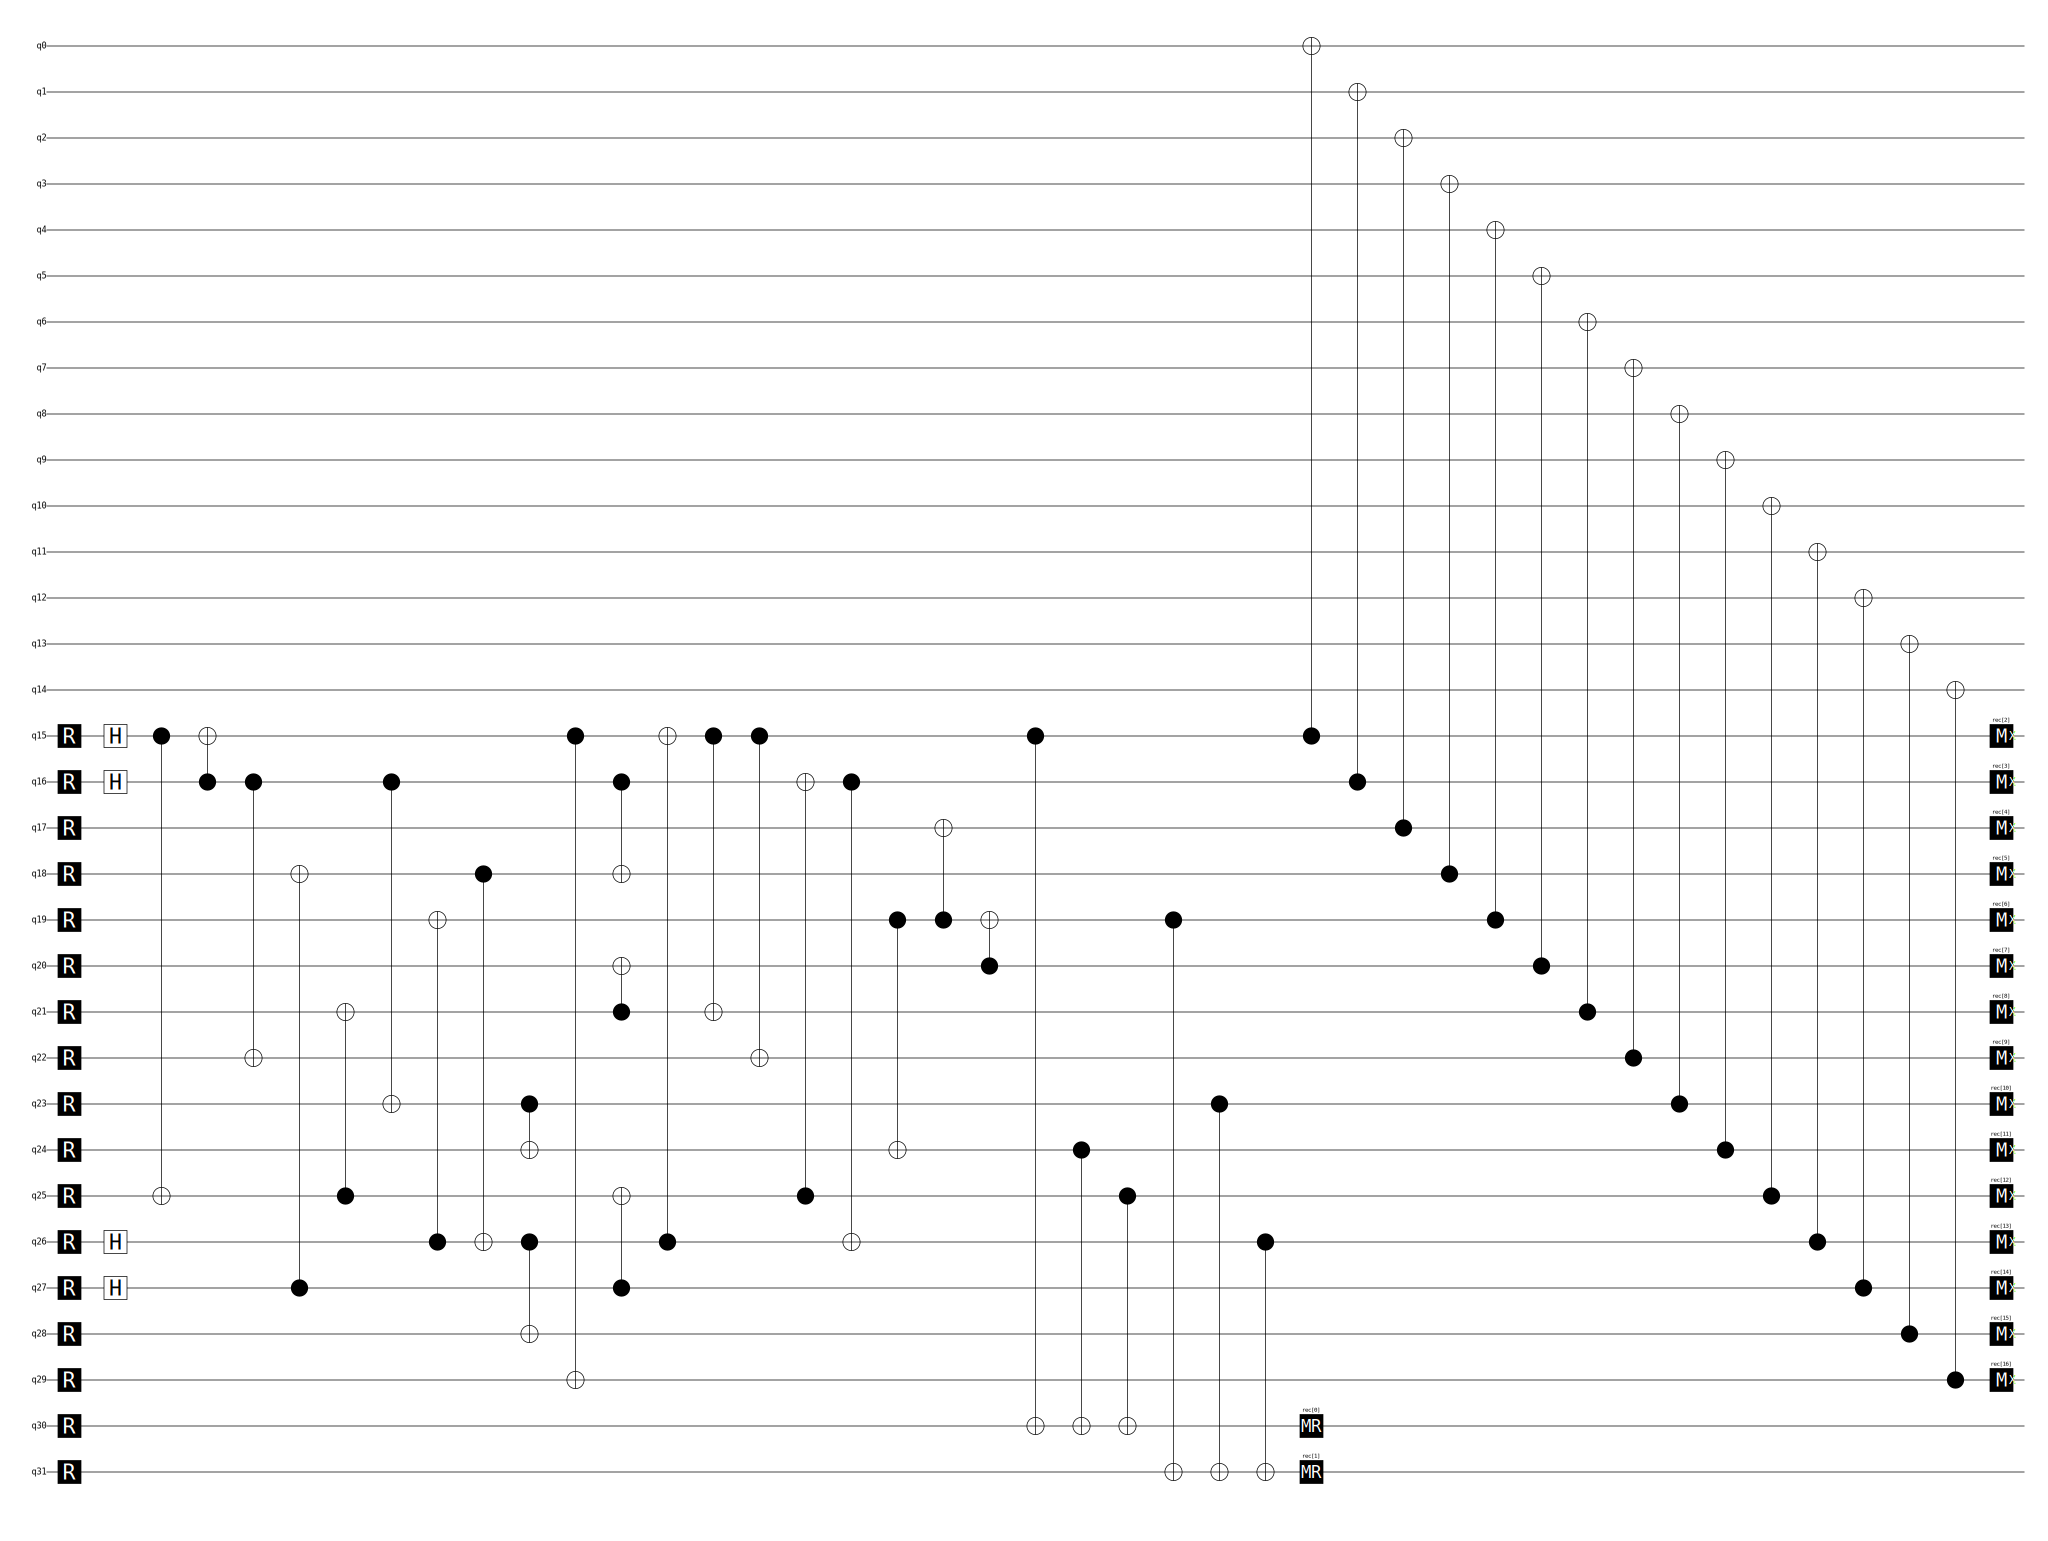

In [11]:
code_name, circuit_path = "7_1_3", "steane/zero_ft_opt_opt"
code_name, circuit_path = "15_7_3", "hamming/zero_ft_opt_opt"

code = CSSCode.load_code("MQT", code_name)
circuit = load_state_prep_circuit("SAT", circuit_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

se.diagram('timeline-svg')

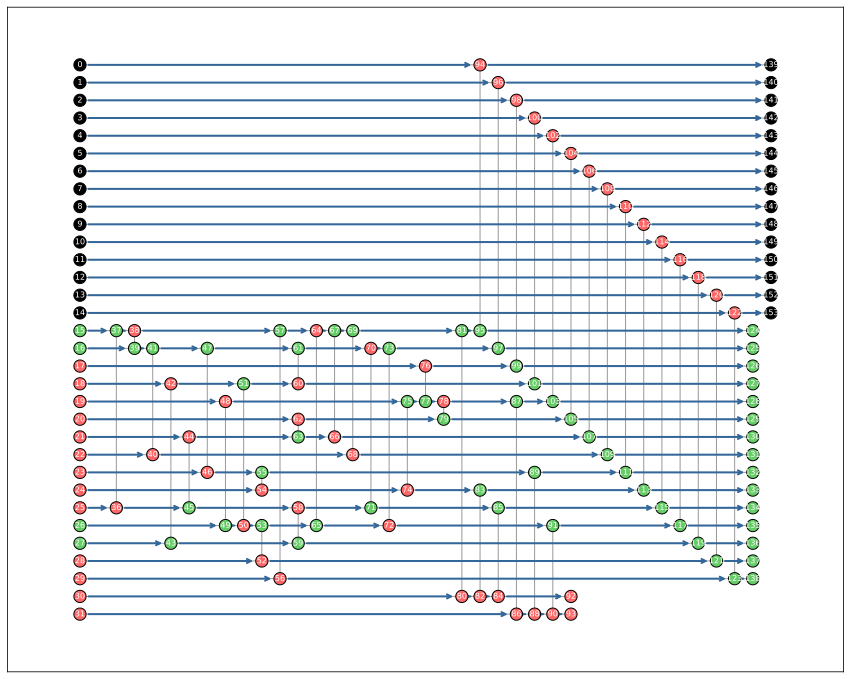

In [12]:
graph = stim_to_pyzx(se, code.n)
cov_graph = CoveredZXGraph.from_zx_diagram(graph)
cov_graph.visualize()

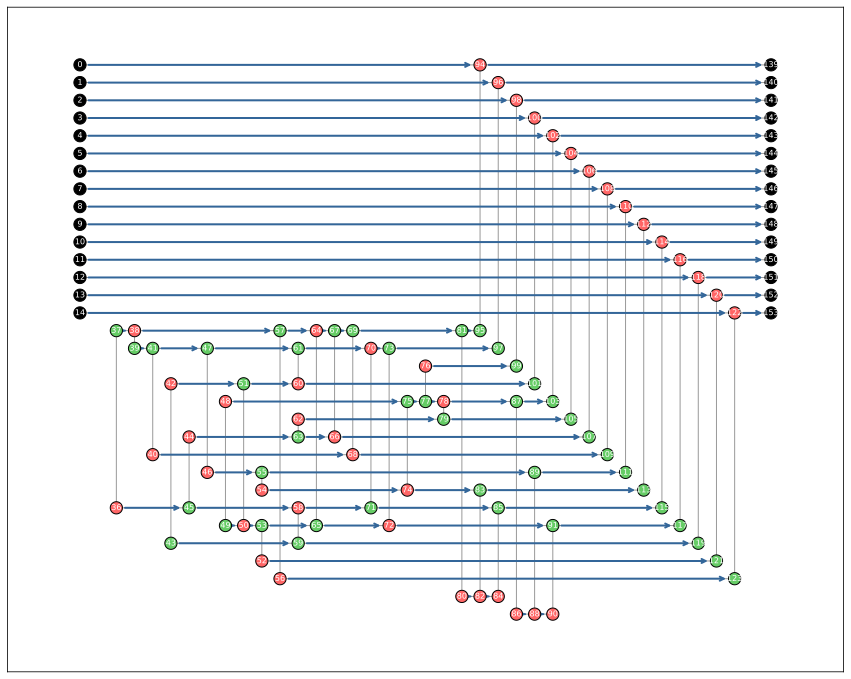

In [13]:
# cov_graph.basic_FE_rewrites()

for v in list(cov_graph.G.nodes()):
    if cov_graph.G.degree(v) == 1 and cov_graph.node_types[v] != zx.VertexType.BOUNDARY:
        [n] = cov_graph.G.neighbors(v)
        cov_graph.fuse(v, n)
cov_graph.visualize()

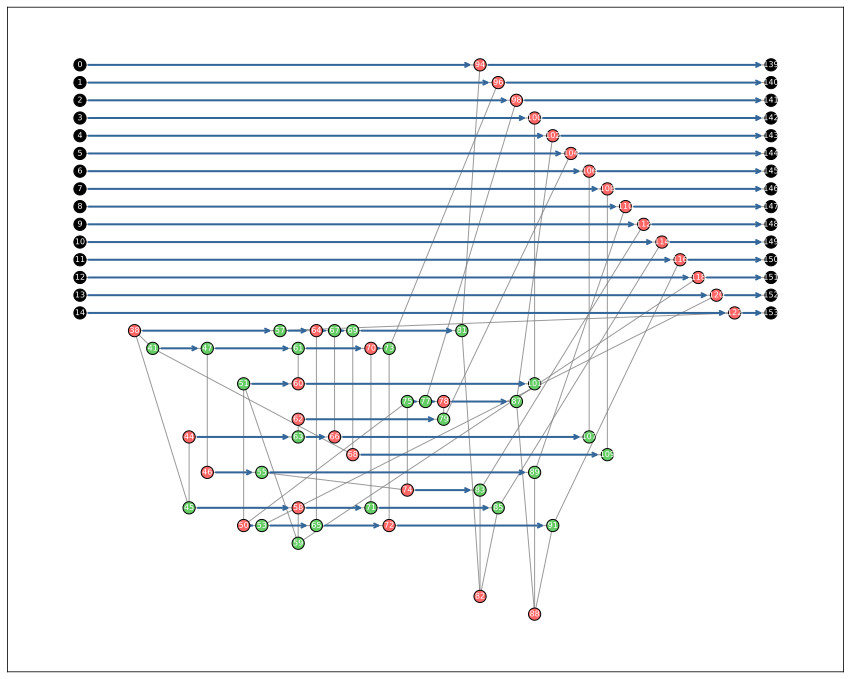

In [14]:
for v in list(cov_graph.G.nodes()):
    cov_graph.remove_id(v)
cov_graph.visualize()

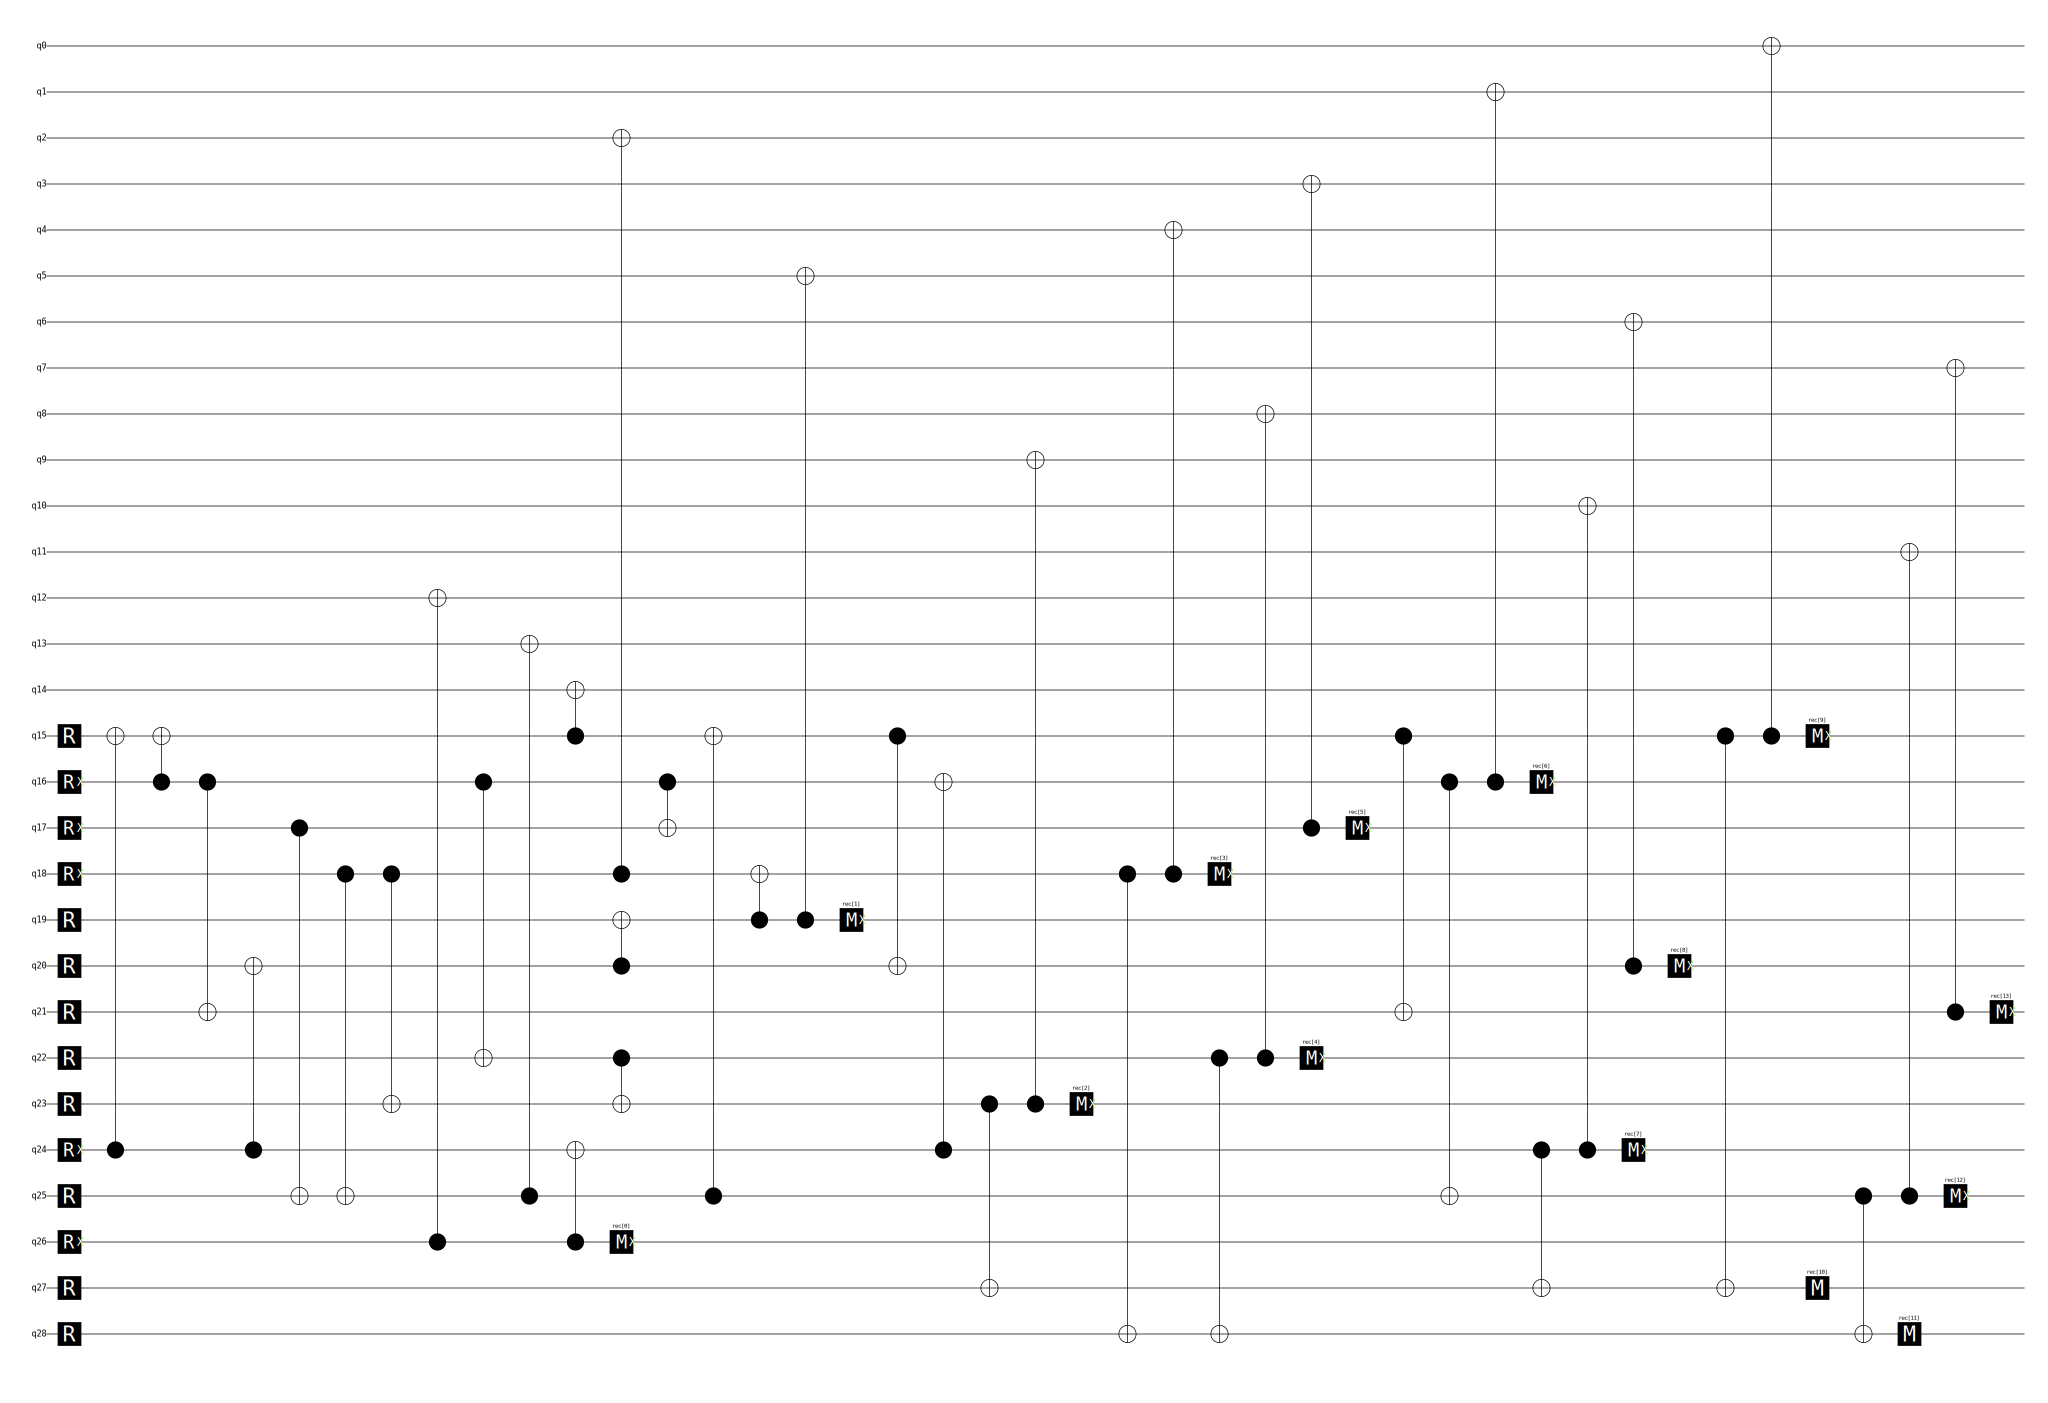

In [15]:
cov_graph.extract_circuit().diagram('timeline-svg')

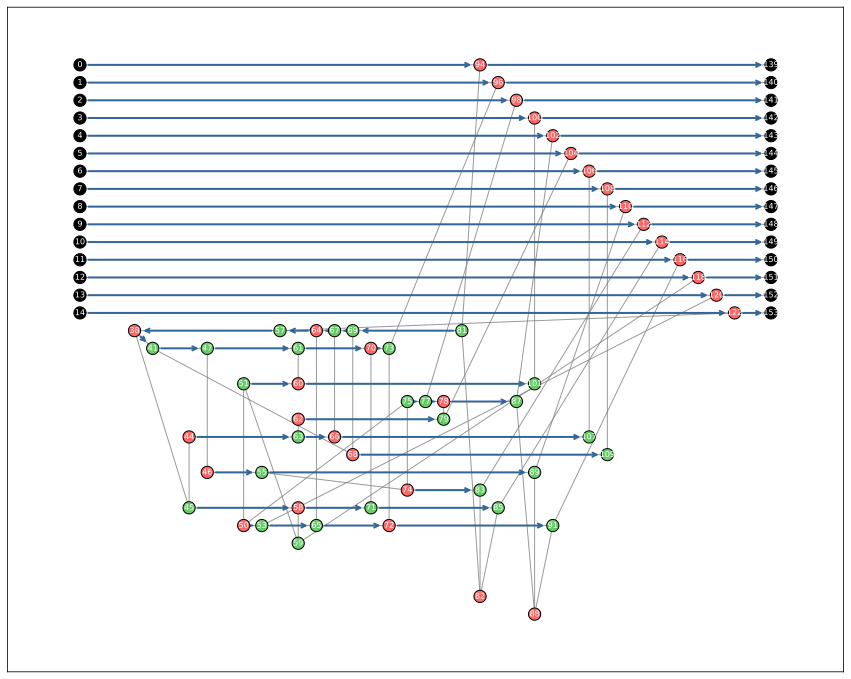

In [16]:
example_bend = cov_graph.copy()
bend = next(example_bend.all_causal_single_boundary_bends())
example_bend.paths = copy.deepcopy(bend)
example_bend.visualize()

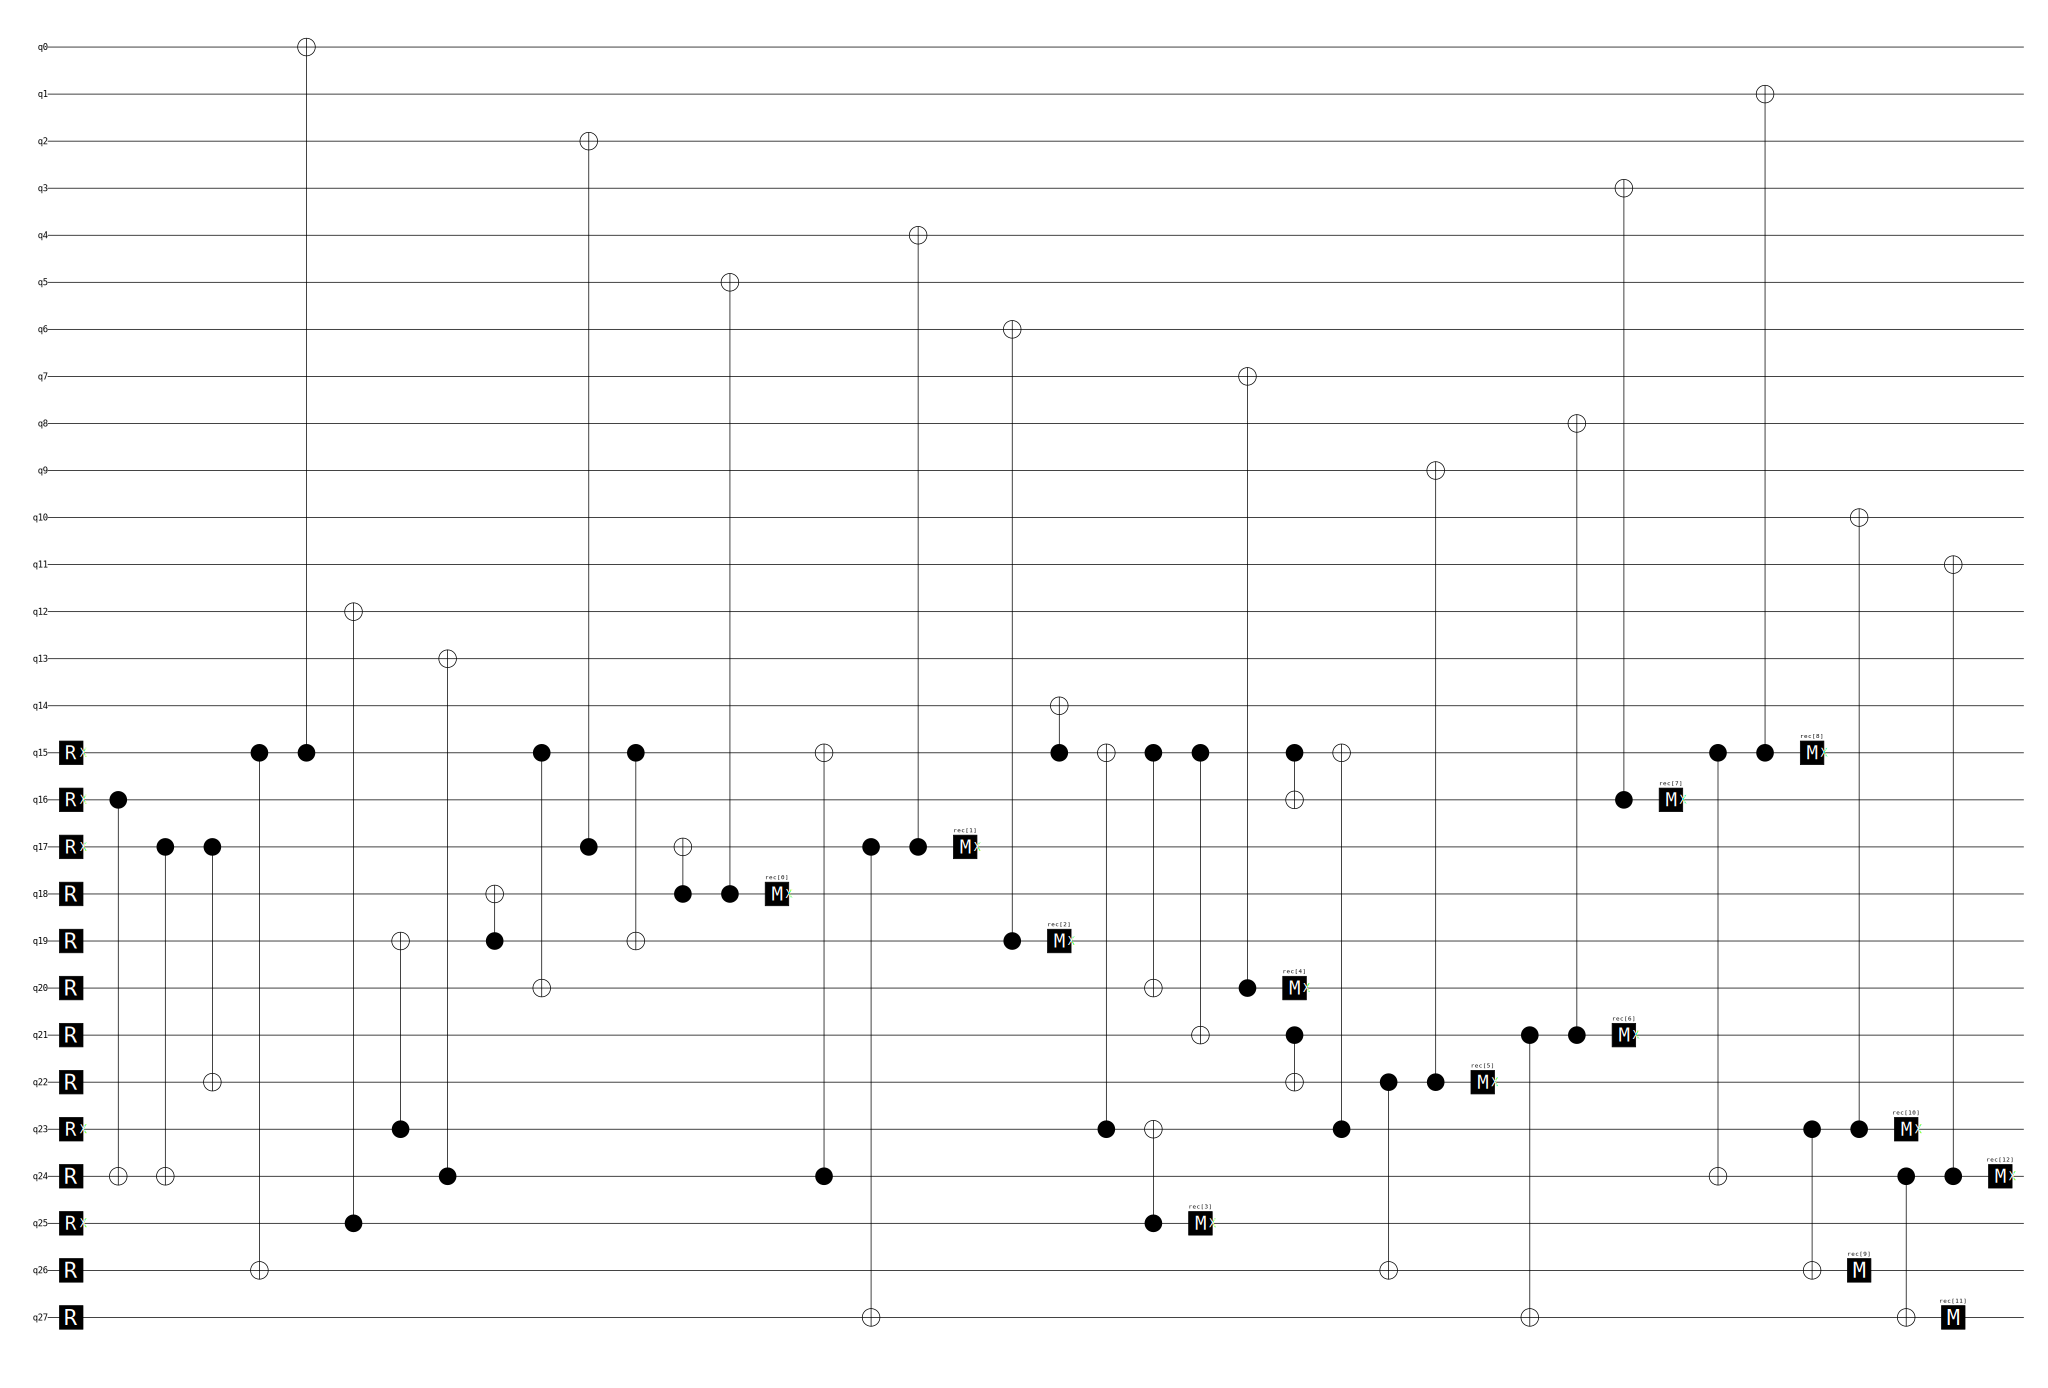

In [17]:
example_bend.extract_circuit().diagram('timeline-svg')

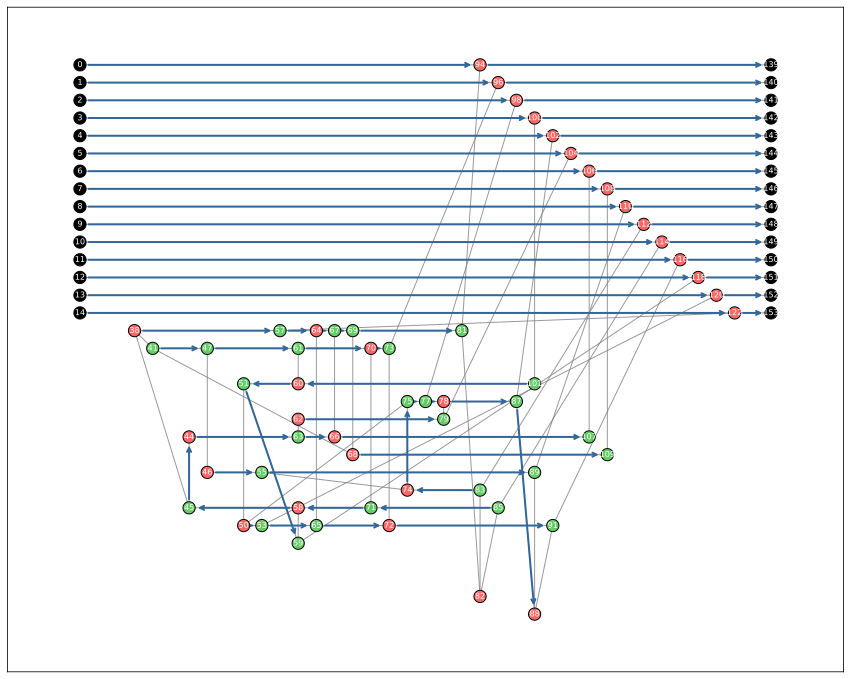

In [18]:
cov_graph_opt = cov_graph.min_ancilla_boundary_bends()[-1]
cov_graph_opt = cov_graph.best_first_boundary_bends(max_evaluations=2_000)
cov_graph_opt.visualize()

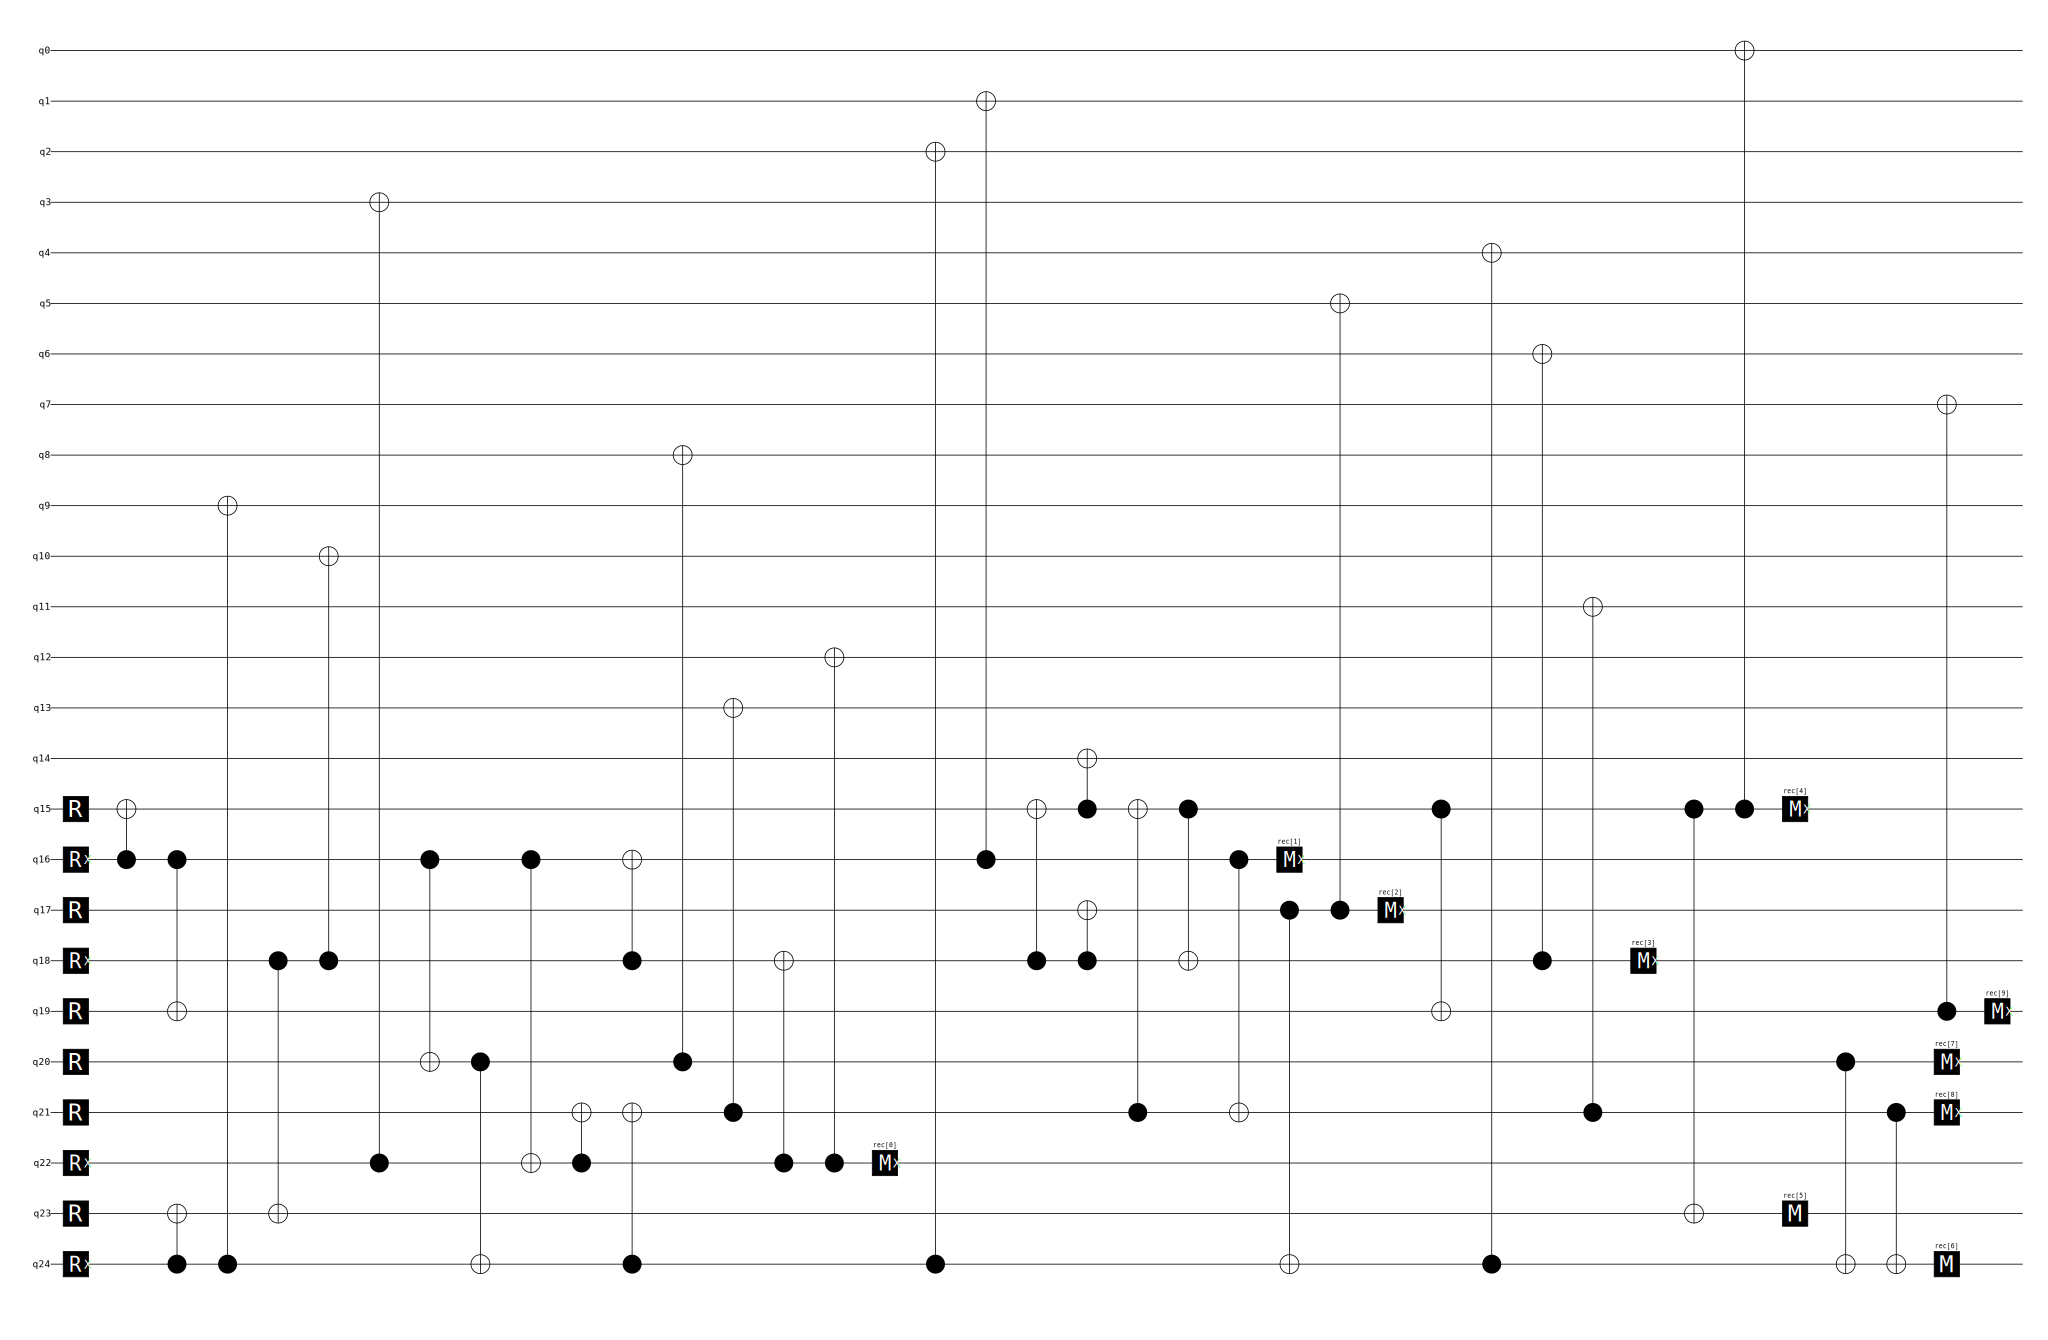

In [19]:
cov_graph_opt.extract_circuit().diagram('timeline-svg')